# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals

---

* **Author**: Carmen-Theodora Craciun
* **Previos step**:
  * all ETL steps from folder `/datasets_ETL`
  * Feature extraction step
* **The purpose of this Notebook**:
* **Datasets**:
  * [Sleep-EDFX Database](https://www.physionet.org/content/sleep-edfx/1.0.0/) - channel EEG Fpz-Cz
  * [University College Dublin Sleep Apnea Database](https://physionet.org/content/ucddb/1.0.0/) - channel EEG C3-A2
  * [Haaglanden Medisch Centrum sleep staging database (PhysioNet)](https://physionet.org/content/hmc-sleep-staging/1.1/recordings/#files-panel) - channel EEG C4-M1
* **Input**:
    * `ML_train_features.csv`
    * `ML_test_features.csv`
    * `ML_test_features.csv`

# Imports

In [3]:
!pip install catboost skrebate

In [4]:
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score, GroupKFold
from imblearn.over_sampling import SMOTE
from collections import Counter
import time
from scipy.signal import medfilt
from sklearn.utils.class_weight import compute_sample_weight
import joblib
import os
from scipy.stats import zscore
from skrebate import ReliefF
from sklearn.model_selection import train_test_split


from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
import xgboost as xgb
import lightgbm as lgb

In [5]:
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/sleep_data/process_dataset'

Mounted at /content/drive


# Datasets

In [6]:
df_train = pd.read_csv(base_path + '/ml_dataset/train_features.csv')
df_val = pd.read_csv(base_path + '/ml_dataset/val_features.csv')

In [7]:
X_train = df_train.drop('Label', axis=1)
y_train = df_train['Label']

X_val = df_val.drop('Label', axis=1)
y_val = df_val['Label']

In [8]:
df_train.head()

,Subject_ID,Dataset_Source,Mean,Std,Skewness,Kurtosis,Zero_Crossings,Mobility,Complexity,Spectral_Entropy,...,Abs_Alpha,Abs_Sigma,Abs_Beta,Abs_Total,Rel_Delta,Rel_Theta,Rel_Alpha,Rel_Sigma,Rel_Beta,Label
0,1,0,-0.429715,50.406050,-26.741851,1125.532264,1153,1.183026,1.331633,4.344991,...,379.917778,352.970003,1291.015457,3872.918762,0.177090,0.124850,0.098096,0.091138,0.333344,0
1,1,0,-0.860650,92.382850,0.635777,8.816965,802,0.116358,12.274820,1.394550,...,24.621977,22.581916,46.442297,9328.269587,0.870715,0.006607,0.002640,0.002421,0.004979,0
2,1,0,1.408013,39.325005,1.371603,9.175044,775,0.143333,9.249867,1.710211,...,23.411200,13.720810,15.159666,1781.254720,0.849699,0.023930,0.013143,0.007703,0.008511,0
3,1,0,0.367535,27.259431,1.709819,17.910265,908,0.192955,7.103479,1.757544,...,15.676385,8.627362,14.673112,1085.139324,0.845470,0.019371,0.014446,0.007950,0.013522,0
4,1,0,-0.572789,15.452458,-0.169122,7.011664,813,0.279101,4.618365,2.513127,...,19.390871,7.220864,10.013620,245.803829,0.709892,0.064260,0.078888,0.029377,0.040738,0


In [9]:
import pandas as pd
from scipy.stats import zscore




# Opțional: conversia Dataset_Source în categorie, dacă este necesar pentru model



# --- PIPELINE 3: Date Normalizate + Feature-uri Temporale Avansate (Recomandat) ---


## Add only Lag/ Lead

In [10]:
def extract_basic_temporal_features(df):
    '''
    Adds temporal context (lag/lead) strictly isolated within each subject's data. This prevents 'data leakage' between different patients.

    Parameters:
    - df (pd.DataFrame): The input DataFrame containing multiple subjects.

    Returns:
    - pd.DataFrame: The DataFrame with patient-isolated temporal context.
    '''
    df_new = df.copy()
    exclude_cols = ['Subject_ID', 'Dataset_Source', 'Label']
    cols_to_shift = [c for c in df_new.columns if c not in exclude_cols]

    def shift_group(group):
        for col in cols_to_shift:
            group[f'{col}_lag2'] = group[col].shift(2)
            group[f'{col}_lag1'] = group[col].shift(1)
            group[f'{col}_lead1'] = group[col].shift(-1)
            group[f'{col}_lead2'] = group[col].shift(-2)
        group.bfill(inplace=True)
        group.ffill(inplace=True)
        return group

    return df_new.groupby('Subject_ID', group_keys=False).apply(shift_group, include_groups=False)

df_train_raw_basic = extract_basic_temporal_features(df_train)
df_val_raw_basic   = extract_basic_temporal_features(df_val)

X_train_raw_basic = df_train_raw_basic.drop(columns=['Label'])
y_train_raw_basic = df_train_raw_basic['Label']
X_val_raw_basic   = df_val_raw_basic.drop(columns=['Label'])
y_val_raw_basic   = df_val_raw_basic['Label']

## Normalise Z-Score

In [11]:
def normalize_by_subject(df, feature_cols):
    '''
    Apply Z-Score normalization per patient (Subject_ID).
    Brings signals from different electrodes (Fpz, C3, C4) to the same common denominator.

    Parameters:
    - df (pd.DataFrame): The input DataFrame.
    - feature_cols (list): List of column names

    Returns:
    - pd.DataFrame: The normalized DataFrame.
    '''
    df_norm = df.copy()
    for col in feature_cols:
        df_norm[col] = df_norm.groupby('Subject_ID')[col].transform(zscore)

    df_norm[feature_cols] = df_norm[feature_cols].fillna(0)
    return df_norm

cols_to_normalize = [
    'Mean', 'Std', 'Skewness', 'Kurtosis', 'Zero_Crossings',
    'Mobility', 'Complexity', 'Spectral_Entropy',
    'Abs_Delta', 'Abs_Theta', 'Abs_Alpha', 'Abs_Sigma', 'Abs_Beta', 'Abs_Total',
    'Rel_Delta', 'Rel_Theta', 'Rel_Alpha', 'Rel_Sigma', 'Rel_Beta'
]

df_train_norm = normalize_by_subject(df_train, cols_to_normalize)
df_val_norm   = normalize_by_subject(df_val, cols_to_normalize)
print(f"Shape after: {df_train_norm.shape}")

Shape after: (228213, 22)


## Lag/ Leag + Z-Score

In [12]:
df_train_norm_basic = extract_basic_temporal_features(df_train_norm)
df_val_norm_basic   = extract_basic_temporal_features(df_val_norm)

df_train_norm_basic['Dataset_Source'] = df_train_norm_basic['Dataset_Source'].astype('category')
df_val_norm_basic['Dataset_Source']   = df_val_norm_basic['Dataset_Source'].astype('category')

X_train_norm_basic = df_train_norm_basic.drop(columns=['Label'])
y_train_norm_basic = df_train_norm_basic['Label']
X_val_norm_basic   = df_val_norm_basic.drop(columns=['Label'])
y_val_norm_basic   = df_val_norm_basic['Label']

## Temporal feature advances + Z-Score

In [ ]:
def extract_enhanced_temporal_features(df):
    '''
    Extract Ratios, Lags, Leads, Diffs and Rolling Stats using ultra-fast vectorized operations, respecting per-patient isolation.

    Parameters:
    - df (pd.DataFrame): The input DataFrame.

    '''
    df_new = df.copy()
    exclude_cols = ['Subject_ID', 'Dataset_Source', 'Label']

    # 1. Creare Ratios (Rapoarte)
    eps = 1e-6
    df_new['Ratio_DeepSleep'] = df_new['Abs_Delta'] / (df_new['Abs_Beta'] + eps)
    df_new['Ratio_Transition'] = df_new['Abs_Theta'] / (df_new['Abs_Alpha'] + eps)

    feature_cols = [c for c in df_new.columns if c not in exclude_cols]
    grouped = df_new.groupby('Subject_ID')[feature_cols]

    # 2. Extragere Lags, Leads și Diferențe vectorizate
    lag1_df = grouped.shift(1).add_suffix('_lag1')
    lag2_df = grouped.shift(2).add_suffix('_lag2')
    lead1_df = grouped.shift(-1).add_suffix('_lead1')
    lead2_df = grouped.shift(-2).add_suffix('_lead2')
    diff_df = df_new[feature_cols].sub(grouped.shift(1)).add_suffix('_diff')

    # 3. Statistici Glisante (Rolling Stats)
    roll_mean_df = grouped.transform(lambda x: x.rolling(window=5, min_periods=1, center=True).mean()).add_suffix('_roll_mean')
    roll_std_df = grouped.transform(lambda x: x.rolling(window=5, min_periods=1, center=True).std()).add_suffix('_roll_std')

    # 4. Concatenare și curățare NaN-uri
    df_final = pd.concat([df_new, lag1_df, lag2_df, lead1_df, lead2_df, diff_df, roll_mean_df, roll_std_df], axis=1)
    df_final = df_final.groupby('Subject_ID', group_keys=False).apply(lambda g: g.bfill().ffill(), include_groups=False)

    return df_final

df_train_norm_enhanced = extract_enhanced_temporal_features(df_train_norm)
df_val_norm_enhanced   = extract_enhanced_temporal_features(df_val_norm)

# Aici dăm drop și la Subject_ID/Dataset_Source, fiindcă modelele bazate pe arbori (RF/XGBoost) nu au nevoie de ele direct
cols_to_drop = ['Subject_ID', 'Dataset_Source', 'Label']

X_train_norm_enhanced = df_train_norm_enhanced.drop(columns=cols_to_drop, errors='ignore')
y_train_norm_enhanced = df_train_norm_enhanced['Label']
X_val_norm_enhanced = df_val_norm_enhanced.drop(columns=cols_to_drop, errors='ignore')
y_val_norm_enhanced = df_val_norm_enhanced['Label']

## ReliefF

In [14]:
def relief_feature_selection(X, y):
    '''
    ReliefF is a filter-type feature selection method that assigns a score to each feature based on how well it distinguishes between similar
    examples from different classes. It is an extension of the Relief algorithm, performing well on multi-class problems and noisy data.

    Parameters:
      - X (pd.DataFrame): The input features.
      - y (pd.Series): The target variable.

    Returns:
      - list: A list of selected feature names.
    '''
    from sklearn.model_selection import train_test_split

    sample_size = 10000

    # Temporarily drop 'Subject_ID' if it exists, as it's typically an identifier, not a feature for ReliefF.
    X_for_relief = X.drop(columns=['Subject_ID'], errors='ignore')

    if len(X_for_relief) > sample_size:
        X_sample, _, y_sample, _ = train_test_split(
            X_for_relief,
            y,
            train_size=sample_size,
            stratify=y,
            random_state=42
        )
    else:
        # Correct typo: 'x' to 'X_for_relief'
        X_sample = X_for_relief.copy()
        y_sample = y.copy()

    # Ensure 'Dataset_Source' is int type if it exists in X_sample, as it's treated as a feature.
    if 'Dataset_Source' in X_sample.columns:
        X_sample['Dataset_Source'] = X_sample['Dataset_Source'].astype(int)

    fs = ReliefF(n_features_to_select=25, n_neighbors=10, n_jobs=-1)
    fs.fit(X_sample.values, y_sample.values)

    top_features = []
    for feature_name, feature_score in zip(X_sample.columns, fs.feature_importances_):
        top_features.append((feature_name, feature_score))

    top_features = sorted(top_features, key=lambda x: x[1], reverse=True)
    selected_columns = [feat[0] for feat in top_features[:25]]

    print("Best 25 features:")
    for name, score in top_features[:25]:
        print(f"{name}: {score:.4f}")

    # Reconstruct cols_to_keep, including 'Subject_ID' and 'Dataset_Source' only if they were in the original X.
    final_cols_to_keep = []
    if 'Subject_ID' in X.columns:
        final_cols_to_keep.append('Subject_ID')
    if 'Dataset_Source' in X.columns:
        final_cols_to_keep.append('Dataset_Source')

    # Add selected features, avoiding duplicates if 'Dataset_Source' is already added.
    for col in selected_columns:
        if col not in final_cols_to_keep:
            final_cols_to_keep.append(col)

    return final_cols_to_keep

In [15]:
cols_to_keep = relief_feature_selection(X_train_raw_basic, y_train_raw_basic)
X_train_relieff_raw_basic = X_train_raw_basic[cols_to_keep].copy()
X_val_relieff_raw_basic = X_val_raw_basic[cols_to_keep].copy()

print(f"\nNew shape: {X_train_relieff_raw_basic.shape}")

Best 25 features:
Zero_Crossings: 0.0947
Zero_Crossings_lag1: 0.0864
Zero_Crossings_lead1: 0.0858
Zero_Crossings_lead2: 0.0856
Zero_Crossings_lag2: 0.0850
Rel_Theta: 0.0811
Spectral_Entropy: 0.0752
Rel_Delta: 0.0727
Mobility: 0.0707
Rel_Beta: 0.0656
Rel_Theta_lag2: 0.0642
Rel_Theta_lead1: 0.0634
Rel_Theta_lag1: 0.0631
Mobility_lag1: 0.0608
Mobility_lead2: 0.0600
Mobility_lead1: 0.0598
Rel_Delta_lag1: 0.0595
Spectral_Entropy_lag2: 0.0590
Rel_Delta_lag2: 0.0589
Rel_Delta_lead1: 0.0584
Mobility_lag2: 0.0584
Rel_Theta_lead2: 0.0581
Rel_Beta_lag1: 0.0573
Spectral_Entropy_lead1: 0.0553
Rel_Delta_lead2: 0.0549

New shape: (228213, 26)


In [16]:
cols_to_keep = relief_feature_selection(X_train_norm_enhanced, y_train_norm_enhanced)
X_train_relieff_norm_enhanced = X_train_norm_enhanced[cols_to_keep].copy()
X_val_relieff_norm_enhanced = X_val_norm_enhanced[cols_to_keep].copy()

print(f"\nNew shape: {X_train_relieff_norm_enhanced.shape}")

Best 25 features:
Rel_Beta_roll_mean: 0.0196
Rel_Theta_roll_mean: 0.0178
Rel_Delta_roll_mean: 0.0152
Zero_Crossings_roll_mean: 0.0143
Std_roll_mean: 0.0138
Zero_Crossings: 0.0128
Spectral_Entropy_roll_std: 0.0128
Rel_Theta_roll_std: 0.0126
Zero_Crossings_lag1: 0.0125
Rel_Beta_lead2: 0.0124
Rel_Beta_lead1: 0.0124
Rel_Theta: 0.0122
Zero_Crossings_lead2: 0.0121
Rel_Theta_lag1: 0.0121
Rel_Theta_lead1: 0.0118
Abs_Theta_roll_mean: 0.0117
Abs_Alpha_roll_mean: 0.0115
Zero_Crossings_lead1: 0.0114
Zero_Crossings_lag2: 0.0113
Rel_Delta_lead1: 0.0113
Rel_Theta_lead2: 0.0110
Mobility_roll_mean: 0.0110
Rel_Sigma_roll_mean: 0.0107
Rel_Delta: 0.0105
Abs_Total_roll_mean: 0.0105

New shape: (228213, 25)


# Generic model functions

## Train and Validate model

In [34]:
def train_model(model, X_train, y_train, X_val, sample_weight=None):
    '''
    Train and validate a machine learning model.

    Parameters:
      - model: The machine learning model to train.
      - X_train (array): Training features.
      - y_train (array): Training labels.
      - X_val (array): Validation features.
      - sample_weight (array, optional): Sample weights for training.
    '''
    start_time_fit = time.time()
    if sample_weight is not None:
        model.fit(X_train, y_train, sample_weight=sample_weight)
    else:
        model.fit(X_train, y_train)
    print(f"Train time: {(time.time() - start_time_fit):.2f} seconds\n")

    return model.predict(X_val)

## Evaluation table

In [18]:
def create_evaluation_table(y_val, y_pred, df_val = df_val):
  '''
  Create a table to evaluate the model's performance.

  Parameters:
    - y_val (array): True labels.
    - y_pred (array): Predicted labels.
    - df_val (pd.DataFrame, optional): DataFrame containing subject IDs and labels.

  Returns:
    - pd.DataFrame: A table with subject IDs, true labels, and predicted labels.
  '''
  df_eval = pd.DataFrame({
      'Subject_ID': df_val['Subject_ID'],
      'Label': y_val,
      'Pred_Raw': y_pred
  })

  df_eval['Pred_Smooth'] = df_eval.groupby('Subject_ID')['Pred_Raw'].transform(
      lambda x: medfilt(x, kernel_size=3).astype(int)
      )

  return df_eval

## Evaluation model

In [25]:
def evaluete_model(y_true, y_pred, class_names=['Wake', 'N1', 'N2', 'N3', 'REM']):
    '''
    Evaluate the performance of a classification model.

    Parameters:
      - y_true (array-like): True labels.
      - y_pred (array-like): Predicted labels.
      - class_names (list): List of class names.
    '''
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy {acc:.4f}\n")

    print("--- Classification report ---")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

# XGBoost, LightGBM & CatBoost

## Baseline LightGBM with SMOTE

In [22]:
print("--- Class distribution before ---")
print(Counter(y_train))

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n--- Class distribution after ---")
print(Counter(y_train_smote))

--- Class distribution before ---
Counter({2: 87244, 0: 48348, 4: 35368, 3: 31587, 1: 25666})

--- Class distribution after ---
Counter({0: 87244, 1: 87244, 2: 87244, 3: 87244, 4: 87244})


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.102847 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5094
[LightGBM] [Info] Number of data points in the train set: 436220, number of used features: 21
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Train time: 60.62 seconds

Accuracy 0.6097

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.68      0.83      0.75     10361
          N1       0.30      0.27      0.28      6930
          N2       0.81      0.55      0.66     20785
          N3       0.65      0.78      0.71      6474
         REM       0.42      0.63      0.51      7574

    accuracy                           0

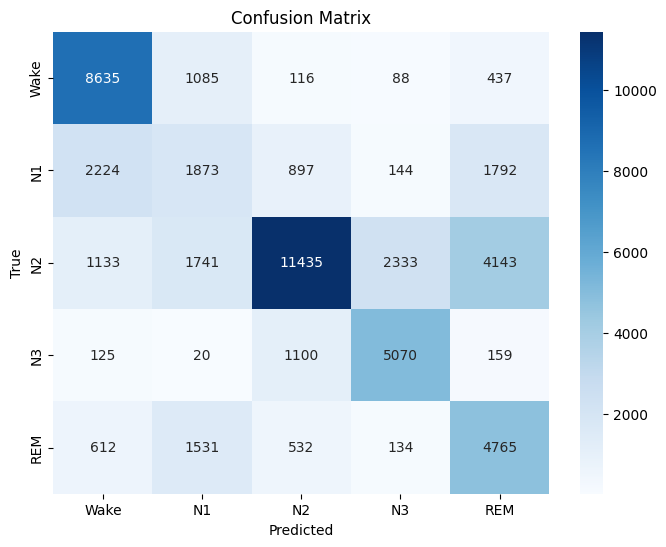

In [26]:
lgb_smote = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    n_jobs=-1
)

y_pred_val_lgb_smote = train_model(lgb_smote, X_train_smote, y_train_smote, X_val)
evaluete_model(y_val, y_pred_val_lgb_smote)

## LightGBM + Lag/Lead + Class Weights

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.265992 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24228
[LightGBM] [Info] Number of data points in the train set: 228213, number of used features: 96
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

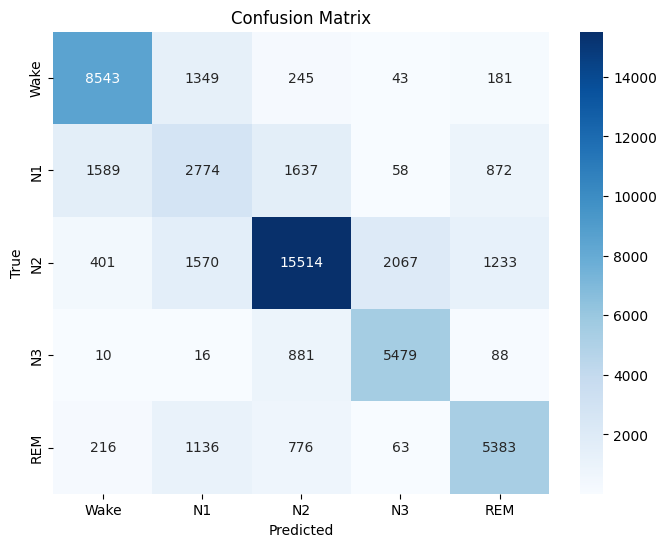

In [20]:
lgb_lag = lgb.LGBMClassifier(
    n_estimators=500, # trees
    learning_rate=0.05,
    max_depth=10,
    num_leaves=150,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

y_pred_lgb_lag = train_model(lgb_lag, X_train_raw_basic, y_train_raw_basic, X_val_raw_basic)

df_eval = create_evaluation_table(y_val_raw_basic, y_pred_lgb_lag)

evaluete_model(df_eval['Label'], df_eval['Pred_Smooth'])

## ! LightGBM + Z-Score + Lag/ Lead

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.285380 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24229
[LightGBM] [Info] Number of data points in the train set: 228213, number of used features: 96
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Train time: 393.54 seconds

Accuracy 0.7324

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.82      0.81      0.82     10361
          N1       0.43      0.40      0.42      6930
          N2       0.79      0.78      0.79     20785
          N3       0.71      0.80      0.75      6474
         REM       0.73      0.74      0.73      7574

    accuracy                          

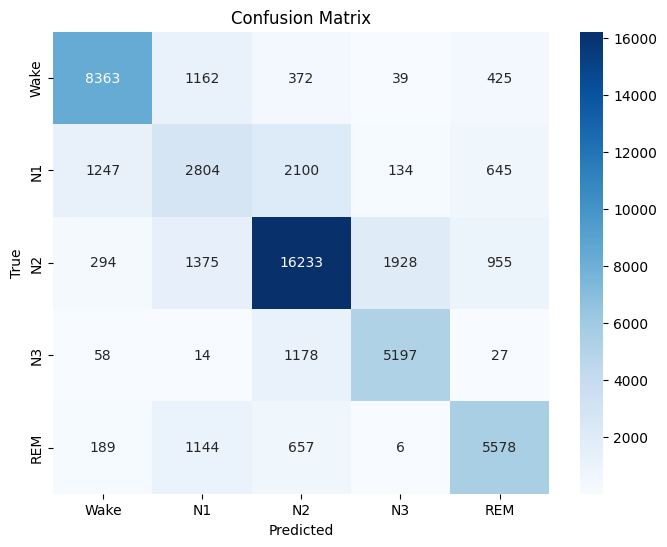

In [27]:
lgb_zscore = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.08,
    max_depth=10,
    num_leaves=125,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

y_pred_lgb_zscore = train_model(lgb_zscore, X_train_norm_basic, y_train_norm_basic, X_val_norm_basic)

df_eval = create_evaluation_table(y_val_norm_basic, y_pred_lgb_zscore)

evaluete_model(df_eval['Label'], df_eval['Pred_Smooth'])

## LightGBM + Advance Temp Context

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.532522 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 42840
[LightGBM] [Info] Number of data points in the train set: 228213, number of used features: 168
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Train time: 719.37 seconds

Accuracy 0.7272

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.81      0.81      0.81     10361
          N1       0.43      0.39      0.41      6930
          N2       0.78      0.78      0.78     20785
          N3       0.70      0.79      0.74      6474
         REM       0.73      0.74      0.74      7574

    accuracy                         

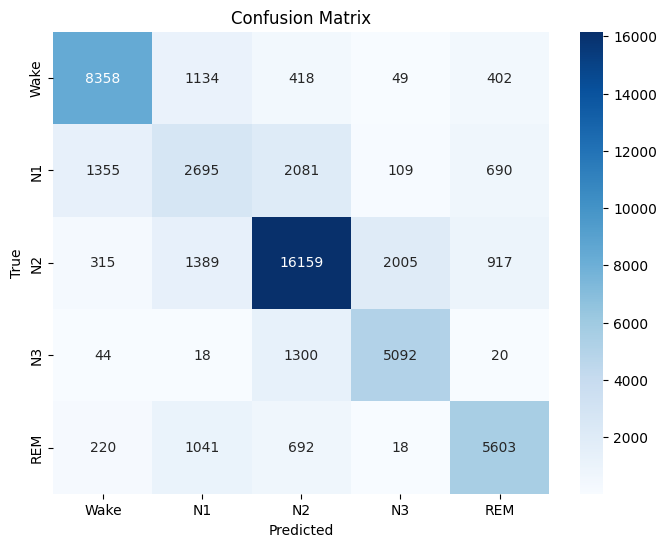

In [28]:
lgb_norm_enhanced = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.08,
    max_depth=10,
    num_leaves=125,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

y_pred_lgb_norm_enhanced = train_model(lgb_norm_enhanced, X_train_norm_enhanced, y_train_norm_enhanced, X_val_norm_enhanced)

df_eval = create_evaluation_table(y_val_norm_enhanced, y_pred_lgb_norm_enhanced)

evaluete_model(df_eval['Label'], df_eval['Pred_Smooth'])

## LightGBM + ReliefF + Lag/Lead

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.066853 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6378
[LightGBM] [Info] Number of data points in the train set: 228213, number of used features: 26
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

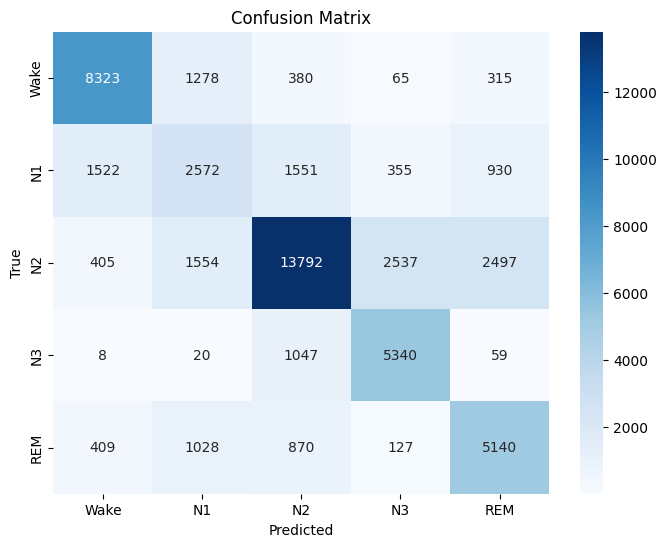

In [29]:
lgb_relieff = lgb.LGBMClassifier(
    n_estimators=500, # trees
    learning_rate=0.05,
    max_depth=10,
    num_leaves=150,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

y_pred_lgb_relieff = train_model(lgb_relieff, X_train_relieff_raw_basic, y_train_raw_basic, X_val_relieff_raw_basic)

df_eval = create_evaluation_table(y_val_raw_basic, y_pred_lgb_relieff)

evaluete_model(df_eval['Label'], df_eval['Pred_Smooth'])

## LightGBM + ReliefF + Advance Temp Context

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.129929 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6375
[LightGBM] [Info] Number of data points in the train set: 228213, number of used features: 25
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

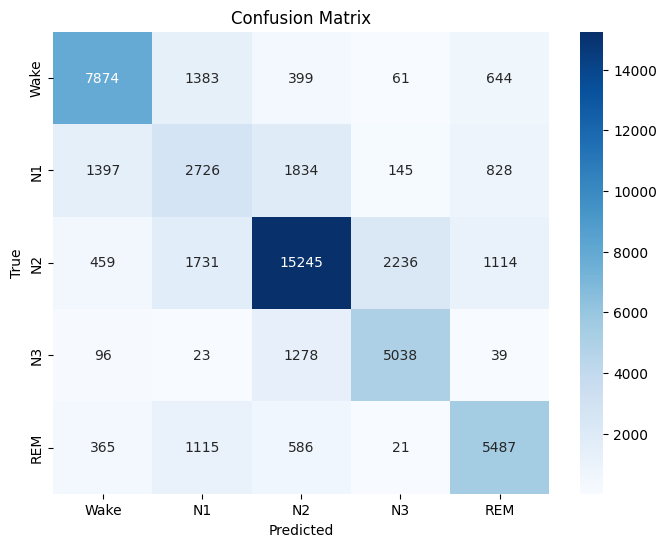

In [30]:
lgb_relieff_enhanced = lgb.LGBMClassifier(
    n_estimators=500, # trees
    learning_rate=0.05,
    max_depth=10,
    num_leaves=150,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

y_pred_lgb_relieff_enhanced = train_model(lgb_relieff_enhanced, X_train_relieff_norm_enhanced, y_train_norm_enhanced, X_val_relieff_norm_enhanced)

df_eval = create_evaluation_table(y_val_norm_enhanced, y_pred_lgb_relieff_enhanced)

evaluete_model(df_eval['Label'], df_eval['Pred_Smooth'])

## XGBoost + Lag/ Lead

Train time: 467.42 seconds

Accuracy 0.7218

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.80      0.82      0.81     10361
          N1       0.41      0.41      0.41      6930
          N2       0.82      0.73      0.77     20785
          N3       0.69      0.86      0.77      6474
         REM       0.70      0.73      0.71      7574

    accuracy                           0.72     52124
   macro avg       0.68      0.71      0.69     52124
weighted avg       0.73      0.72      0.72     52124



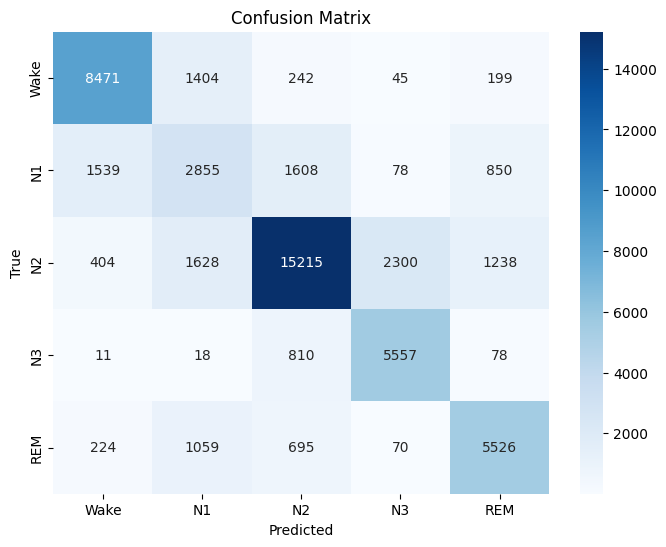

In [35]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_norm_basic)

xgb_lag = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=400,
    learning_rate=0.08,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    enable_categorical=True,
    n_jobs=-1
)

y_pred_xgb_lag = train_model(
    xgb_lag, X_train_raw_basic, y_train_raw_basic, X_val_raw_basic, sample_weights
    )

df_eval = create_evaluation_table(y_val_raw_basic, y_pred_xgb_lag)
evaluete_model(df_eval['Label'], df_eval['Pred_Smooth'])

## ! XGBoost + Advance Temporal Context

Train time: 958.81 seconds

Accuracy 0.7241

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.82      0.80      0.81     10361
          N1       0.42      0.41      0.42      6930
          N2       0.80      0.76      0.78     20785
          N3       0.69      0.81      0.74      6474
         REM       0.72      0.75      0.73      7574

    accuracy                           0.72     52124
   macro avg       0.69      0.70      0.70     52124
weighted avg       0.73      0.72      0.72     52124



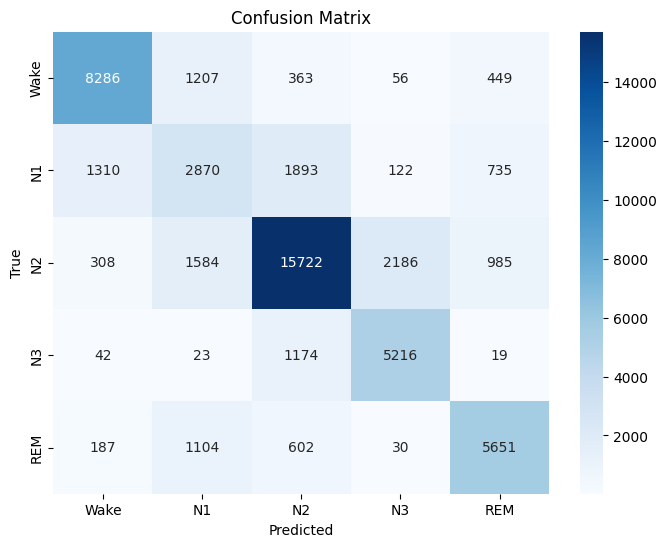

In [36]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_norm_basic)

xgb_norm_enhanced = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=400,
    learning_rate=0.08,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    enable_categorical=True,
    n_jobs=-1
)

y_pred_xgb_norm_enhanced = train_model(
    xgb_norm_enhanced, X_train_norm_enhanced, y_train_norm_enhanced, X_val_norm_enhanced, sample_weights
    )

df_eval = create_evaluation_table(y_val_raw_basic, y_pred_xgb_norm_enhanced)

evaluete_model(df_eval['Label'], df_eval['Pred_Smooth'])

## XGBoost + ReliefF

Train time: 157.03 seconds

Accuracy 0.6957

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.75      0.77     10361
          N1       0.40      0.41      0.41      6930
          N2       0.80      0.72      0.75     20785
          N3       0.65      0.80      0.72      6474
         REM       0.67      0.73      0.70      7574

    accuracy                           0.70     52124
   macro avg       0.66      0.68      0.67     52124
weighted avg       0.70      0.70      0.70     52124



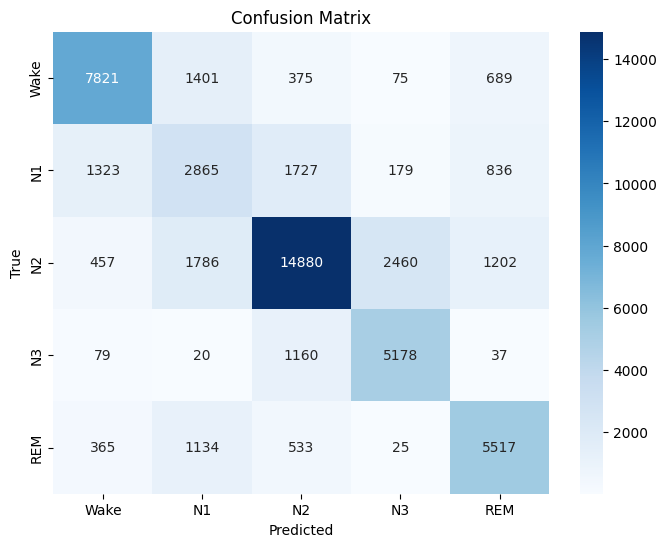

In [37]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_norm_basic)

xgb_relieff_enhanced = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=400,
    learning_rate=0.08,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    enable_categorical=True,
    n_jobs=-1
)

y_pred_xgb_relieff_enhanced = train_model(
    xgb_relieff_enhanced, X_train_relieff_norm_enhanced, y_train_norm_enhanced, X_val_relieff_norm_enhanced, sample_weights
    )

df_eval = create_evaluation_table(y_val_raw_basic, y_pred_xgb_relieff_enhanced)

evaluete_model(df_eval['Label'], df_eval['Pred_Smooth'])

## CatBoost

In [38]:
X_train_cat = X_train_norm_basic.copy()
X_val_cat = X_val_norm_basic.copy()

X_train_cat['Dataset_Source'] = X_train_cat['Dataset_Source'].astype(int)
X_val_cat['Dataset_Source'] = X_val_cat['Dataset_Source'].astype(int)
categorical_features_indices = ['Dataset_Source']

cat_model = CatBoostClassifier(
    iterations=500,              # Trees
    learning_rate=0.08,
    depth=8,                     # Maximum depth of synthetic trees
    auto_class_weights='Balanced',
    cat_features=categorical_features_indices,
    random_seed=42,
    verbose=100                  # Shows progress every 100 steps
)

start_time = time.time()
cat_model.fit(X_train_cat, y_train_norm_basic, eval_set=(X_val_cat, y_val_norm_basic), early_stopping_rounds=50)
print(f"Train time: {(time.time() - start_time):.2f} secunde")

y_pred_raw_cat = cat_model.predict(X_val_cat).flatten() # Flatten because it returns a 2D array

df_eval_cat = pd.DataFrame({
    'Subject_ID': df_val['Subject_ID'],
    'Label': y_val_norm_basic,
    'Pred_Raw': y_pred_raw_cat
})

df_eval_cat['Pred_Smooth'] = df_eval_cat.groupby('Subject_ID')['Pred_Raw'].transform(lambda x: medfilt(x, kernel_size=3).astype(int))
evaluete_model(df_eval_cat['Label'], df_eval_cat['Pred_Smooth'])

0:	learn: 1.5127159	test: 1.5189991	best: 1.5189991 (0)	total: 3.77s	remaining: 31m 23s
100:	learn: 0.7055836	test: 0.8202108	best: 0.8202108 (100)	total: 6m 23s	remaining: 25m 13s
200:	learn: 0.6228651	test: 0.7867265	best: 0.7867265 (200)	total: 12m 37s	remaining: 18m 46s
300:	learn: 0.5736631	test: 0.7721721	best: 0.7721561 (299)	total: 18m 48s	remaining: 12m 26s
400:	learn: 0.5378258	test: 0.7626284	best: 0.7626284 (400)	total: 24m 59s	remaining: 6m 10s


KeyboardInterrupt: 

# Random Forest

## RF with Temporal Context

In [ ]:
rf_norm_enhanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

y_rf_pred_norm_enhanced = train_model(rf_norm_enhanced, X_train_norm_enhanced, y_train_norm_enhanced, X_val_norm_enhanced)

evaluete_model(y_val_norm_enhanced, y_rf_pred_norm_enhanced)

## RF Divide et Impera

Train time: 1166.07 seconds
Accuracy 0.6980

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.84      0.66      0.74     10361
          N1       0.44      0.27      0.33      6930
          N2       0.69      0.87      0.77     20785
          N3       0.78      0.67      0.72      6474
         REM       0.67      0.69      0.68      7574

    accuracy                           0.70     52124
   macro avg       0.68      0.63      0.65     52124
weighted avg       0.69      0.70      0.69     52124



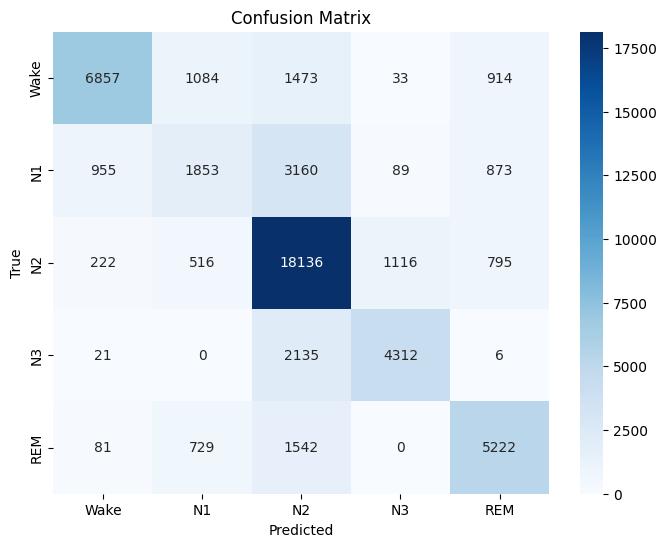

In [ ]:
start_time = time.time()

# Sleep vs wake
y_train_bin = y_train_norm_enhanced.apply(lambda x: 0 if x == 0 else 1)
rf_binary = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_binary.fit(X_train_norm_enhanced, y_train_bin)

# Only sleep stages
mask_sleep = y_train_norm_enhanced != 0
X_train_sleep = X_train_norm_enhanced[mask_sleep]
y_train_sleep = y_train_norm_enhanced[mask_sleep]

rf_sleep = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_sleep.fit(X_train_sleep, y_train_sleep)

# Combine
preds_bin = rf_binary.predict(X_val_norm_enhanced)
preds_sleep = rf_sleep.predict(X_val_norm_enhanced)
y_pred_ierarhic = np.where(preds_bin == 0, 0, preds_sleep)

print(f"Train time: {round((time.time() - start_time), 2)} seconds")
evaluete_model(y_val_norm_enhanced, y_pred_ierarhic)

## RF Clinical Approach

In [ ]:
# Combining N1 and N2
y_train_4c = y_train_norm_enhanced.replace({1: 2})
y_val_4c = y_val_norm_enhanced.replace({1: 2})


rf_4c = RandomForestClassifier(
    n_estimators=150,
    class_weight='balanced',
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
rf_4c.fit(X_train_norm_enhanced, y_train_4c)
print(f"Train time: {round((time.time() - start_time), 2)} seconds")

y_pred_4c = rf_4c.predict(X_val_norm_enhanced)

clase_4 = ['Wake', 'N2', 'N3', 'REM']

evaluete_model(y_val_4c, y_pred_4c, class_names=clase_4)

To understand the limitations of Random Forest on this dataset, we conducted a secondary experiment in which we merged the N1 transition stage with the N2 stage.

In this 4-class configuration, the accuracy of the Random Forest model artificially increased to 77.14%. This experiment clearly demonstrates that the proposed algorithms are extremely capable of understanding the macro-structure of sleep, but the capping at ~73% in the real clinical scenario (5 classes) is strictly caused by the impossibility of separating the EEG waves from the N1 stage from those from Wake and N2 in the absence of eye movement (EOG) sensors.

# REDO - Cross-validation - Gradient Boosting Ensemble

# Test Dataset

In [ ]:
# df_test = pd.read_csv(base_path + '/ml_dataset/test_features.csv')

# df_test_norm = normalize_by_subject(df_test, col_to_normalize)
# df_test_norm_basic = extract_basic_temporal_features(df_test_norm)
# df_test_norm_basic['Dataset_Source'] = df_test_norm_basic['Dataset_Source'].astype('category')

# X_test_norm_basic = df_test_norm_basic.drop(['Label'], axis=1)
# y_test_norm_basic = df_test_norm_basic['Label']

# test_subjects = df_test['Subject_ID']
# y_test_final = df_test_norm_basic['Label']

# # A. Setul pentru LightGBM și XGBoost (Eliminăm Label)
# X_test_tree = df_test_norm_basic.drop(['Label'], axis=1).copy()
# # Dataset_Source este deja 'category' din codul tău anterior, deci e perfect!

# # B. Setul pentru CatBoost (Dataset_Source trebuie să fie int)
# X_test_cat = df_test_norm_basic.drop(['Label'], axis=1).copy()
# X_test_cat['Dataset_Source'] = X_test_cat['Dataset_Source'].astype(int)

In [ ]:
models_path = base_path + "/../models/"  # Sau cum l-ai definit tu exact

lgb_loaded = joblib.load(models_path + 'best_lgb.pkl')

xgb_loaded = xgb.XGBClassifier()
xgb_loaded.load_model(models_path + 'best_xgb.json')

cat_loaded = CatBoostClassifier()
cat_loaded.load_model(models_path + 'best_cat.cbm')

df_eval_test = pd.DataFrame({
    'Subject_ID': test_subjects.values,
    'Label': y_test_final.values
})

In [ ]:
probs_lgb = lgb_loaded.predict_proba(X_test_tree)

y_pred_raw_lgb = np.argmax(probs_lgb, axis=1)
df_eval_test['Pred_LGB'] = y_pred_raw_lgb
df_eval_test['Smooth_LGB'] = df_eval_test.groupby('Subject_ID')['Pred_LGB'].transform(lambda x: medfilt(x, kernel_size=5).astype(int))
acc_lgb = accuracy_score(df_eval_test['Label'], df_eval_test['Smooth_LGB'])
print(f"Accuracy LightGBM: {acc_lgb:.4f}\n")

probs_xgb = xgb_loaded.predict_proba(X_test_tree)

y_pred_raw_xgb = np.argmax(probs_xgb, axis=1)
df_eval_test['Pred_XGB'] = y_pred_raw_xgb
df_eval_test['Smooth_XGB'] = df_eval_test.groupby('Subject_ID')['Pred_XGB'].transform(lambda x: medfilt(x, kernel_size=5).astype(int))
acc_xgb = accuracy_score(df_eval_test['Label'], df_eval_test['Smooth_XGB'])
print(f"\nAccuracy XGBoost:  {acc_xgb:.4f}\n")

probs_cat = cat_loaded.predict_proba(X_test_cat)

y_pred_raw_cat = np.argmax(probs_cat, axis=1)
df_eval_test['Pred_CAT'] = y_pred_raw_cat
df_eval_test['Smooth_CAT'] = df_eval_test.groupby('Subject_ID')['Pred_CAT'].transform(lambda x: medfilt(x, kernel_size=5).astype(int))
acc_cat = accuracy_score(df_eval_test['Label'], df_eval_test['Smooth_CAT'])
print(f"\nAccuracy CatBoost: {acc_cat:.4f}")

print("\n------------------------")
probs_ensemble = (probs_lgb + probs_xgb + probs_cat) / 3.0

y_pred_raw_3way = np.argmax(probs_ensemble, axis=1)

df_eval_test['Pred_Raw'] = y_pred_raw_3way
df_eval_test['Pred_Smooth'] = df_eval_test.groupby('Subject_ID')['Pred_Raw'].transform(lambda x: medfilt(x, kernel_size=5).astype(int))

acc_ens = accuracy_score(df_eval_test['Label'], df_eval_test['Pred_Smooth'])

evaluete_model(df_eval_test['Label'], df_eval_test['Pred_Smooth'])